# Testing a two model structure to isolate the text sentiment from the market data

Ok so I THINK that our models are struggling because they are trying to learn both the market movement patterns and the sentiment analysis from text at the same time. 

Our TF IDF vectors are extremely large, with thousands of dimensions, while our market data is only 2 features.

I think the models aren't even using the market data because it's so insignificant compared to the thousands of text features.

### So what if we separate the two tasks?

I believe this is called stacking.

We will have one model analyze the sentiment of the text, then feed the sentiment along with the pct_change and volume into our second model to make a decision.

After doing additional research, I think we should use a tree based model for the second model, since they can capture non-linear relationships and interactions between features better than linear models. The main reason I thought of this is because it would be able to capture the idea that when the volume is large, no matter if the pct_change is positive or negative, it will increase whatever the effect of it is. That cannot be modeled linearly. 

For the first model, we can keep our SGDClassifier, after we tuned the parameters using GridSearchCV in Phase 3, it performed the best out of all our models. 

For the second model, I think we should try XGBoost since it's another tree method that we didn't cover in class and supposedly can be more accurate.

Before we begin, we have to very carefully think about DATA LEAKAGE!

The issue we could run into is, if we train model A on the entire training set, then use it to generate predictions for model B on the training set, model A will have already seen those examples, so model B will learn to trust model A too much.

We can avoid this by using cross-validation to generate model A's predictions on the training set. This way, model A will only make predictions on examples it hasn't seen during training, giving model B realistic predictions to learn from.

In [241]:
%%capture
%pip install xgboost

In [242]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

# Training our first model to analyze text sentiment using SGDClassifier

In [243]:
df = pd.read_csv("data/extra_and_merged_data.csv", index_col="date", parse_dates=True)
df.sort_index(inplace=True)

We define our features (X) and target (y)

Our features (X) is comprised of our cleaned text data (X1) and our financial data (X2).

In [244]:
X = df[["summary", "pct_change", "volume"]]
y = df["target"]

Now we split our data for training and testing

DO NOT SHUFFLE because we don't want to mix time series data

In [245]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [246]:
print(f"Training Range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing Range:  {X_test.index.min()} to {X_test.index.max()}")

Training Range: 2003-02-20 00:00:00 to 2018-03-23 00:00:00
Testing Range:  2018-03-26 00:00:00 to 2021-12-30 00:00:00


we will use TF-IDF vectorization to convert text into numerical format


In [247]:
text_pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
        ),
        (
            "sgd",
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=1e-4,
                random_state=42,
                max_iter=1000,
                class_weight="balanced",
            ),
        ),
    ]
)

IMPORTANT BEFORE WE FIT (I originally forgot this oops)

We need to use TimeSeriesSplit to avoid data leakage when generating predictions for the training set

In [248]:
tscv = TimeSeriesSplit(n_splits=5)

In [249]:
meta_predictions = []
meta_indices = []

for split_idx, (train_index, test_index) in enumerate(tscv.split(X_train)):
    # Create the fold data
    fold_X_train = X_train["summary"].iloc[train_index]
    fold_y_train = y_train.iloc[train_index]
    fold_X_test = X_train["summary"].iloc[test_index]

    # Fit on the past
    text_pipeline.fit(fold_X_train, fold_y_train)

    # Predict on the "future" (this fold's test set)
    probs = text_pipeline.predict_proba(fold_X_test)[:, 1]

    # Store results
    meta_predictions.append(probs)
    meta_indices.append(test_index)

# Flatten the results
# This array contains predictions for the later part of X_train
train_sentiment_probs = np.concatenate(meta_predictions)
valid_indices = np.concatenate(meta_indices)

# We create a new training set that only includes rows where we have
# valid out-of-fold predictions.
X_train_meta = X_train.iloc[valid_indices][["pct_change", "volume"]].copy()
y_train_meta = y_train.iloc[valid_indices]

# Add the sentiment score feature
X_train_meta["sentiment_score"] = train_sentiment_probs

Fit this to ONLY the text column of our data

In [250]:
text_pipeline.fit(X_train['summary'], y_train)

,steps,"[('tfidf', ...), ('sgd', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


Now we can generate sentiment scores (basically probabilities), so we convert the messy text vectors into a clean number 0.0 to 1.0 

In [251]:
test_sentiment = text_pipeline.predict_proba(X_test['summary'])[:, 1]
X_test_meta = X_test[['pct_change', 'volume']].copy()
X_test_meta['sentiment_score'] = test_sentiment

Now we make the model

In [252]:
xgb_model = XGBClassifier(
    n_estimators=100,  # number of trees
    max_depth=4,  # maximum depth of each tree
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
)

In [253]:
xgb_model.fit(X_train_meta, y_train_meta)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [254]:
y_pred = xgb_model.predict(X_test_meta)

In [255]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5300

Classification Report:
              precision    recall  f1-score   support

         0.0       0.43      0.27      0.33       413
         1.0       0.56      0.73      0.64       536

    accuracy                           0.53       949
   macro avg       0.50      0.50      0.48       949
weighted avg       0.51      0.53      0.50       949



           Feature  Importance
2  sentiment_score    0.354438
1           volume    0.346822
0       pct_change    0.298740


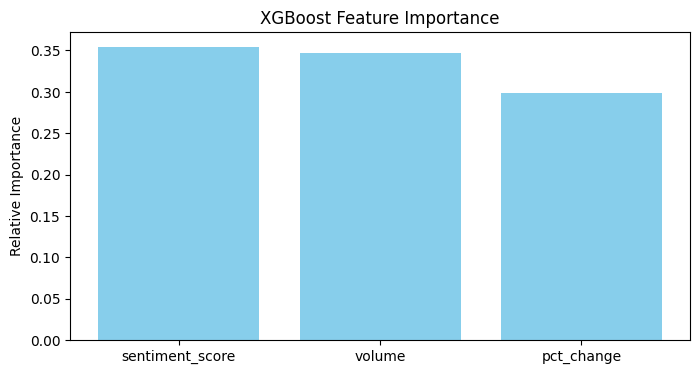

In [256]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
feature_names = X_train_meta.columns

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp)

plt.figure(figsize=(8, 4))
plt.bar(feat_imp['Feature'], feat_imp['Importance'], color='skyblue')
plt.title('XGBoost Feature Importance')
plt.ylabel('Relative Importance')
plt.show()

Originally we had 91% reliance on sentiment_score, and the other two were practically nothing. 

After tuning, by preventing data leakage, we have a more balanced feature importance

### Unfortunately...

Our results got worse. Our accuracy has now dropped to 52%. 

### But the good news is...

Our results are now honest. We know for a fact that it is considering all three features, and that it is not cheating by peeking at the training data because of our data leakage prevention.



We should now check which of the models in our stack is failing. If the first model isn't accurately predicting sentiment, then the second model will never have a chance to succeed.

In [257]:
# Predicting only the text pipeline for comparison
y_pred_text_only = text_pipeline.predict(X_test['summary'])

acc_text = accuracy_score(y_test, y_pred_text_only)
print(f"Text-Only Accuracy: {acc_text:.4f}")

print("\nClassification Report (Text Only):")
print(classification_report(y_test, y_pred_text_only))

conf_mat = confusion_matrix(y_test, y_pred_text_only)
print("\nConfusion Matrix:")
print(conf_mat)

Text-Only Accuracy: 0.5279

Classification Report (Text Only):
              precision    recall  f1-score   support

         0.0       0.44      0.30      0.36       413
         1.0       0.57      0.70      0.63       536

    accuracy                           0.53       949
   macro avg       0.50      0.50      0.49       949
weighted avg       0.51      0.53      0.51       949


Confusion Matrix:
[[124 289]
 [159 377]]


I won't repeat the cells for this, but I noticed that the recall for 0 and 1 on the text prediction was way overfavoring the market going up. So it is suffering from optimist bias and just betting on the market going up, because historically it does, but it's not actually trying to predict whether it will be 0 or 1. 

I tried to improve this by adding class_weight="balanced" to the SGDClassifier parameters to force it to care about both classes equally. However, this only increased the recall to a .3, .7 split, which is better but still not great.

At this point I think maybe I can use GridSearchCV to tune the hyperparameters of the SGDClassifier to see if I can get it to perform better.

### Tuning text model with GridSearchCV

Before I get started, I need to clarify my goals for the tuning. I do NOT want to target accuracy, because accuracy can be misleading in imbalanced datasets. Instead, I want to maximize the F1-score, which balances precision and recall.

I can do this for both 1 and 0 by using 'f1_macro' as the scoring parameter in GridSearchCV. This takes the average of the f1 score for both 0 and 1. This way, I ensure that the model performs well across both classes, rather than just optimizing for the majority class.

In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("sgd", SGDClassifier(loss="log_loss", random_state=42, max_iter=1000)),
    ]
)

param_grid = {
    "tfidf__ngram_range": [
        # (1, 1),
        (1, 2),
        (1, 3),
    ],  # Test unigrams, bigrams, and trigrams
    "tfidf__max_features": [3000, 5000, 10000],  # How huge should the vocabulary be?
    "tfidf__min_df": [
        2,
        5,
    ],  # Ignore words that appear less than X times (removes typos/noise)
    "sgd__loss": ["log_loss", "hinge"],  # 'log_loss'=Logistic Regression, 'hinge'=SVM
    "sgd__alpha": [1e-4, 1e-3, 1e-2],  # Regularization (prevent overfitting)
    "sgd__penalty": ["l2", "elasticnet"],  # Penalty type
    "sgd__class_weight": ["balanced", None],  # Fix the "Optimist" bias
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=16,
    verbose=1,
)

grid_search.fit(X_train["summary"], y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Macro: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test["summary"])

print("\n--- Optimized Model Results ---")
print(classification_report(y_test, y_pred_grid))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_grid))

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters: {'sgd__alpha': 0.01, 'sgd__class_weight': None, 'sgd__loss': 'log_loss', 'sgd__penalty': 'l2', 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV F1-Macro: 0.5449

--- Optimized Model Results ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       413
         1.0       0.56      1.00      0.72       536

    accuracy                           0.56       949
   macro avg       0.28      0.50      0.36       949
weighted avg       0.32      0.56      0.41       949


Confusion Matrix:
[[  0 413]
 [  0 536]]


C:\Users\vince\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vince\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vince\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

You need the F1-Macro score to be noticeably higher than 0.50. If you get 0.54 with a balanced confusion matrix (meaning it predicts "Down" correctly a decent amount of the time), you have a winner.******


8

8

8

8

8

8
